In [1]:
import torch
from torch import nn, optim
from torchvision import datasets, transforms
import torchvision.transforms as T
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from tqdm import tqdm

# CIFAR 10

In [2]:
train_dataset = datasets.CIFAR10(
    'data',
    train=True,
    download=True,
    transform=T.ToTensor()
)
test_dataset = datasets.CIFAR10(
    'data',
    train=False,
    download=True,
    transform=T.ToTensor()
)

100%|██████████| 170M/170M [00:06<00:00, 27.5MB/s]


torch.Size([3, 32, 32]) 6


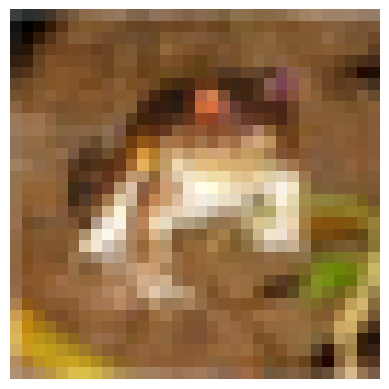

In [3]:
img, label = train_dataset[0]
print(img.shape, label)
plt.axis("off")
plt.imshow(img.permute(1, 2, 0))
plt.show()

In [4]:
train_dataloader = DataLoader(train_dataset, batch_size=512, shuffle=True, num_workers=2)
test_dataloader = DataLoader(test_dataset, batch_size=512, shuffle=False, num_workers=2)

In [5]:
class MyNet(nn.Module):
    def __init__(self, input_size: int, output_size: int) -> None:
        super().__init__()
        self.seq = nn.Sequential(
            nn.Linear(input_size, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, output_size)
        )

    def forward(self, x):
        x = self.seq(x)
        return x

In [6]:
def train(model, train_dataloader, criterion, optimizer, num_epoch):
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    model = model.to(device)
    train_loss = []
    train_acc = []
    for epoch in range(num_epoch):
        print(f"\nEpoch {epoch + 1}/{num_epoch}")
        running_loss = 0.0
        running_acc = 0.0
        for images, labels in tqdm(train_dataloader):
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            images = images.flatten(1)
            outputs = model(images)

            loss = criterion(outputs, labels)
            preds = outputs.argmax(dim=1)
            acc = (preds == labels).float().mean()

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            running_acc += acc.item() * images.size(0)

        epoch_loss = running_loss / len(train_dataloader.dataset)
        epoch_acc = running_acc / len(train_dataloader.dataset) * 100
        print(f"Loss: {epoch_loss:.4f} | ACC: {epoch_acc:.2f}%")
        train_loss.append(epoch_loss)
        train_acc.append(epoch_acc)

    return train_loss, train_acc

In [7]:
torch.cuda.manual_seed_all(42)
model = MyNet(32*32*3, 10)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
num_epoch = 10
train_loss, train_acc = train(model, train_dataloader, criterion, optimizer, num_epoch)


Epoch 1/10


100%|██████████| 98/98 [00:06<00:00, 14.10it/s]


Loss: 1.9802 | ACC: 27.36%

Epoch 2/10


100%|██████████| 98/98 [00:08<00:00, 12.17it/s]


Loss: 1.7654 | ACC: 36.54%

Epoch 3/10


...

Loss: 1.4431 | ACC: 48.33%

Epoch 9/10


100%|██████████| 98/98 [00:06<00:00, 15.71it/s]


Loss: 1.4316 | ACC: 48.98%

Epoch 10/10


100%|██████████| 98/98 [00:07<00:00, 12.67it/s]

Loss: 1.3965 | ACC: 50.21%


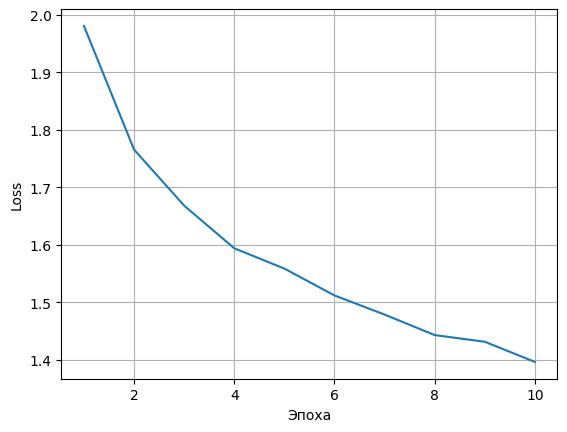

In [8]:
epochs = range(1, num_epoch + 1)
plt.plot(epochs, train_loss)
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

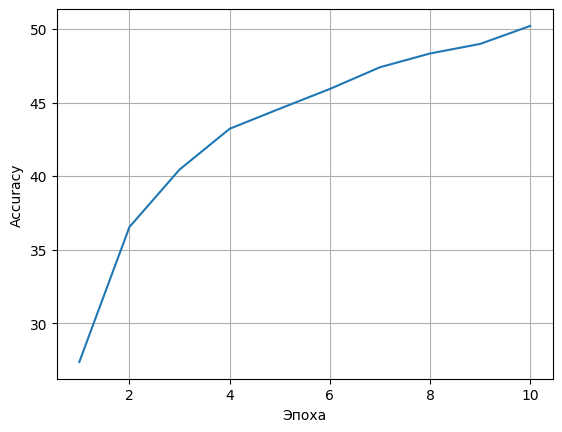

In [9]:
plt.plot(epochs, train_acc)
plt.xlabel('Эпоха')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()

# Без регуляризации

In [10]:
torch.cuda.manual_seed_all(42)
model = MyNet(32*32*3, 10)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
num_epoch = 10
train_loss_without_reg, train_acc_without_reg = train(model, train_dataloader, criterion, optimizer, num_epoch)


Epoch 1/10


100%|██████████| 98/98 [00:06<00:00, 15.05it/s]


Loss: 1.9643 | ACC: 27.84%

Epoch 2/10


100%|██████████| 98/98 [00:07<00:00, 12.50it/s]


Loss: 1.7368 | ACC: 37.32%

Epoch 3/10


...

Loss: 1.4382 | ACC: 48.88%

Epoch 9/10


100%|██████████| 98/98 [00:07<00:00, 13.33it/s]


Loss: 1.4164 | ACC: 49.65%

Epoch 10/10


100%|██████████| 98/98 [00:06<00:00, 14.85it/s]

Loss: 1.3881 | ACC: 50.68%


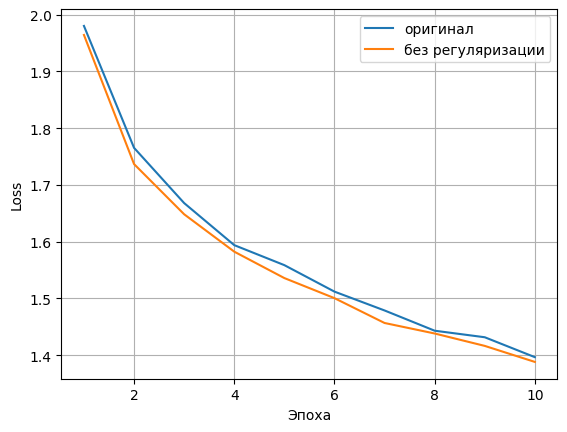

In [14]:
plt.plot(epochs, train_loss, label='оригинал')
plt.plot(epochs, train_loss_without_reg, label='без регуляризации')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

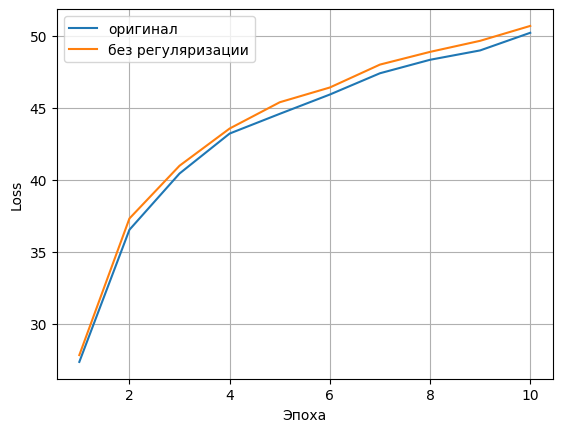

In [15]:
plt.plot(epochs, train_acc, label='оригинал')
plt.plot(epochs, train_acc_without_reg, label='без регуляризации')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# Заменяем relu на сигмоиду

In [16]:
class MySigmoidNet(nn.Module):
    def __init__(self, input_size: int, output_size: int) -> None:
        super().__init__()
        self.seq = nn.Sequential(
            nn.Linear(input_size, 512),
            nn.Sigmoid(),
            nn.Linear(512, 256),
            nn.Sigmoid(),
            nn.Linear(256, 128),
            nn.Sigmoid(),
            nn.Linear(128, output_size)
        )

    def forward(self, x):
        x = self.seq(x)
        return x

In [17]:
torch.cuda.manual_seed_all(42)
model = MySigmoidNet(32*32*3, 10)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
num_epoch = 10
train_loss_sigmoid, train_acc_sigmoid = train(model, train_dataloader, criterion, optimizer, num_epoch)


Epoch 1/10


100%|██████████| 98/98 [00:06<00:00, 14.12it/s]


Loss: 2.0897 | ACC: 21.17%

Epoch 2/10


100%|██████████| 98/98 [00:08<00:00, 12.25it/s]


Loss: 1.8891 | ACC: 30.86%

Epoch 3/10


...

Loss: 1.6044 | ACC: 41.66%

Epoch 9/10


100%|██████████| 98/98 [00:08<00:00, 11.56it/s]


Loss: 1.5718 | ACC: 43.11%

Epoch 10/10


100%|██████████| 98/98 [00:06<00:00, 14.67it/s]

Loss: 1.5402 | ACC: 44.42%


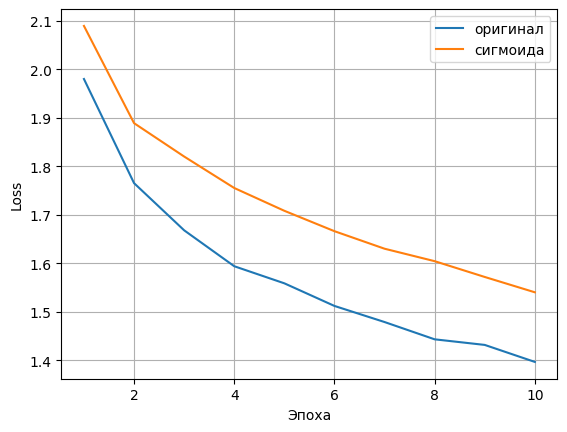

In [39]:
plt.plot(epochs, train_loss, label='оригинал')
plt.plot(epochs, train_loss_sigmoid, label='сигмоида')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()
plt.show()

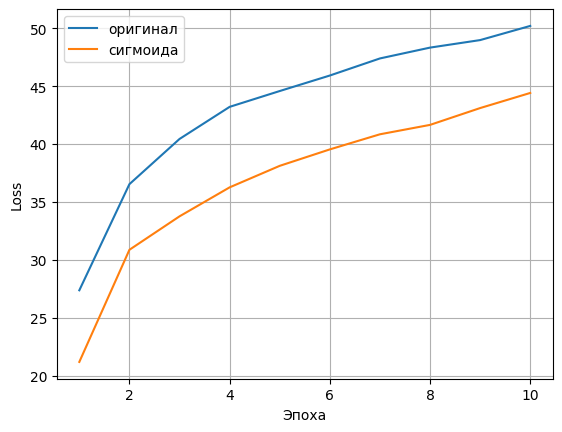

In [19]:
plt.plot(epochs, train_acc, label='оригинал')
plt.plot(epochs, train_acc_sigmoid, label='сигмоида')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# CNN

In [22]:
def train(model, train_dataloader, criterion, optimizer, num_epoch):
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    model = model.to(device)
    train_loss = []
    train_acc = []
    for epoch in range(num_epoch):
        print(f"\nEpoch {epoch + 1}/{num_epoch}")
        running_loss = 0.0
        running_acc = 0.0
        for images, labels in tqdm(train_dataloader):
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, labels)
            preds = outputs.argmax(dim=1)
            acc = (preds == labels).float().mean()

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            running_acc += acc.item() * images.size(0)

        epoch_loss = running_loss / len(train_dataloader.dataset)
        epoch_acc = running_acc / len(train_dataloader.dataset) * 100
        print(f"Loss: {epoch_loss:.4f} | ACC: {epoch_acc:.2f}%")
        train_loss.append(epoch_loss)
        train_acc.append(epoch_acc)

    return train_loss, train_acc

In [23]:
class MyCNN(nn.Module):
    def __init__(self, input_size: int, output_size: int) -> None:
        super().__init__()

        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.act = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(kernel_size=2)
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(64 * 8 * 8, output_size)



    def forward(self, x):
        x = self.conv1(x)
        x = self.act(x)
        x = self.pool1(x)
        x = self.conv2(x)
        x = self.act(x)
        x = self.pool2(x)
        x = self.flatten(x)
        x = self.fc1(x)
        return x

In [24]:
torch.cuda.manual_seed_all(42)
model = MyCNN(32*32*3, 10)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
num_epoch = 10
train_loss_cnn, train_acc_cnn = train(model, train_dataloader, criterion, optimizer, num_epoch)


Epoch 1/10


100%|██████████| 98/98 [00:09<00:00, 10.57it/s]


Loss: 1.7922 | ACC: 36.37%

Epoch 2/10


100%|██████████| 98/98 [00:07<00:00, 13.78it/s]


Loss: 1.4380 | ACC: 49.33%

Epoch 3/10


...

Loss: 1.0276 | ACC: 64.74%

Epoch 9/10


100%|██████████| 98/98 [00:08<00:00, 11.71it/s]


Loss: 0.9957 | ACC: 65.67%

Epoch 10/10


100%|██████████| 98/98 [00:08<00:00, 11.93it/s]

Loss: 0.9631 | ACC: 67.04%


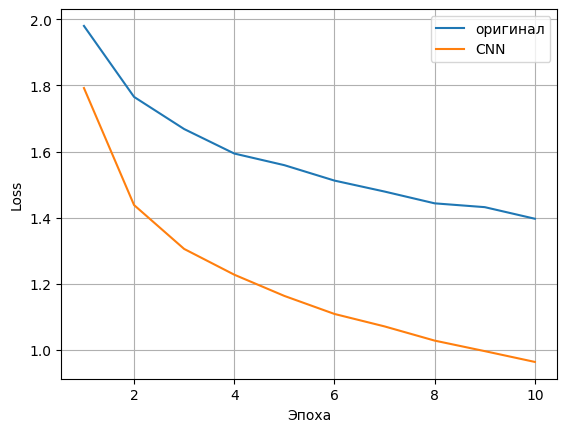

In [40]:
plt.plot(epochs, train_loss, label='оригинал')
plt.plot(epochs, train_loss_cnn, label='CNN')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()
plt.show()

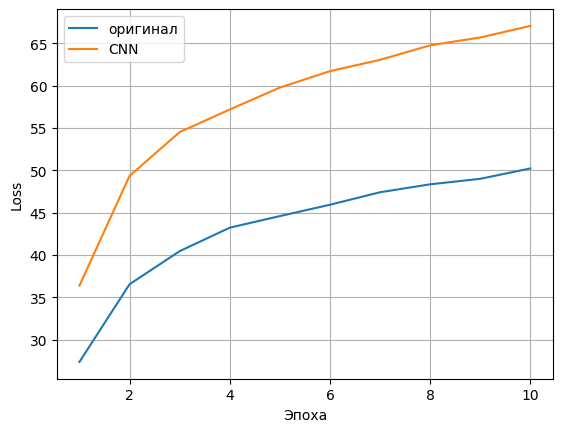

In [26]:
plt.plot(epochs, train_acc, label='оригинал')
plt.plot(epochs, train_acc_cnn, label='CNN')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [31]:
image, _ = next(iter(test_dataloader))
device = 'cuda' if torch.cuda.is_available() else 'cpu'
with torch.no_grad():
    image = image.to(device)
    activation1 = model.conv1(image)
    activation1 = model.act(activation1)
    activation2 = model.pool1(activation1)
    activation2 = model.conv2(activation2)
    activation2 = model.act(activation2)

# После первой свертки

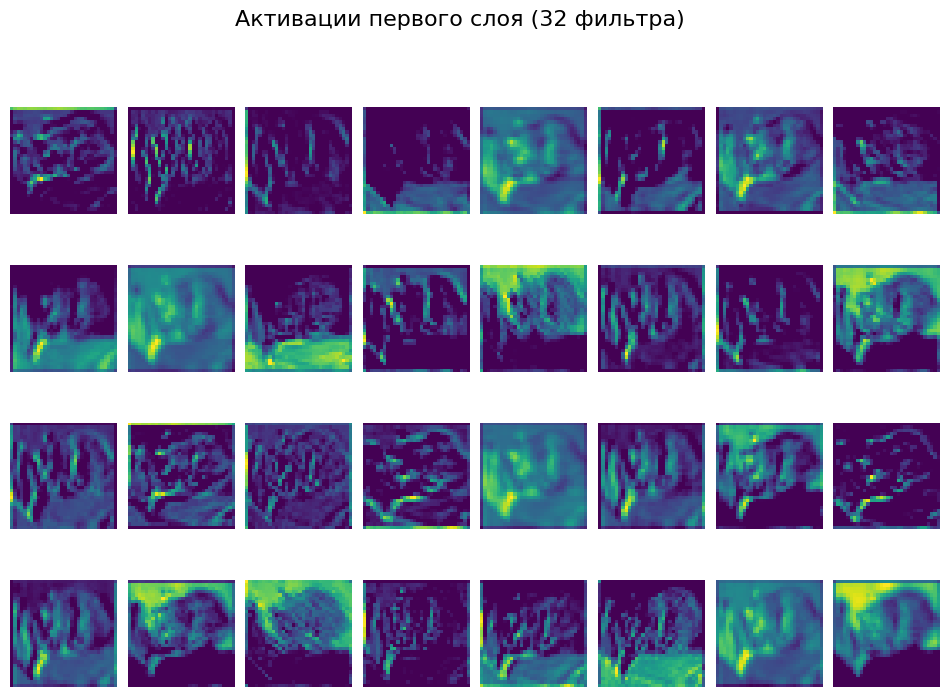

In [38]:
act_maps = activation1[0].cpu().detach().numpy()
fig, axes = plt.subplots(4, 8, figsize=(12, 8))

for i, ax in enumerate(axes.flat):
    ax.imshow(act_maps[i])
    ax.axis('off')

plt.subplots_adjust(wspace=0.1, hspace=0.1)
plt.suptitle('Активации первого слоя (32 фильтра)', fontsize=16)
plt.show()

# После второй свертки

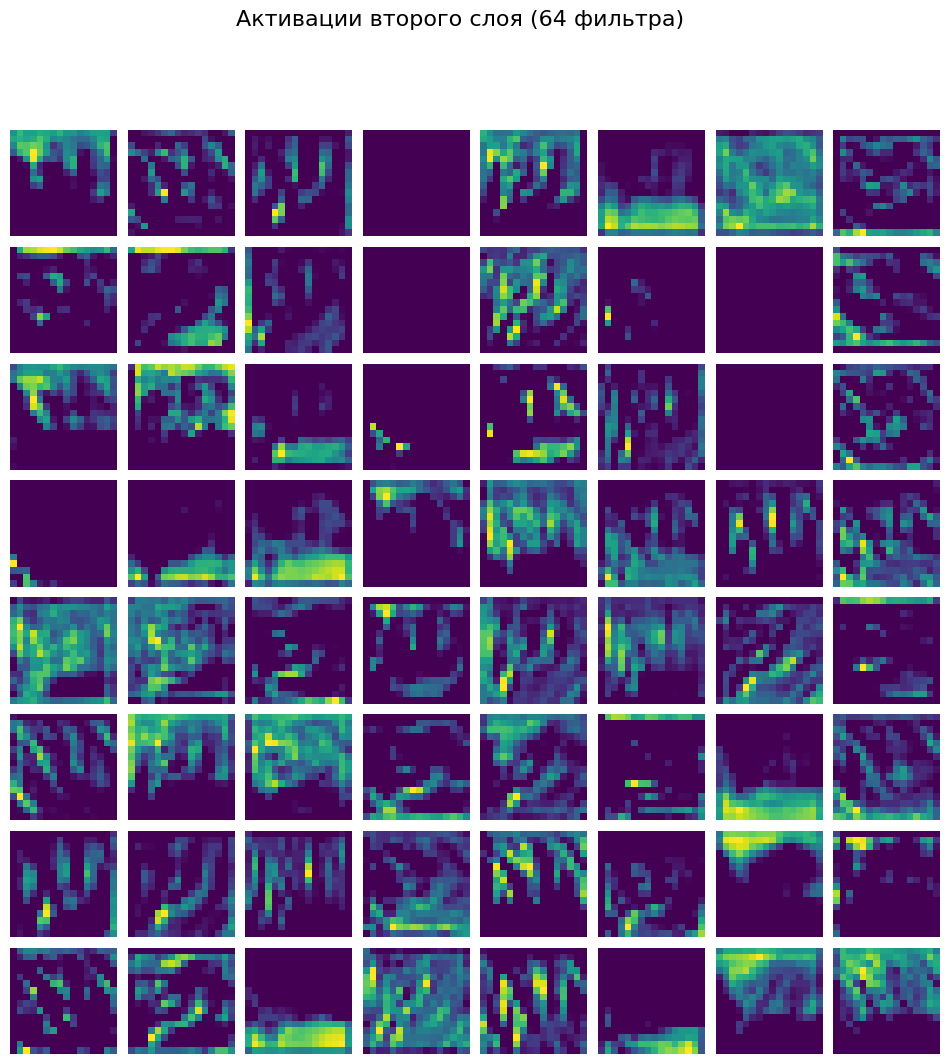

In [36]:
act_maps = activation2[0].cpu().detach().numpy()

fig, axes = plt.subplots(8, 8, figsize=(12, 12))

for i, ax in enumerate(axes.flat):
    ax.imshow(act_maps[i])
    ax.axis('off')

plt.subplots_adjust(wspace=0.1, hspace=0.1)
plt.suptitle('Активации второго слоя (64 фильтра)', fontsize=16)
plt.show()